In [13]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

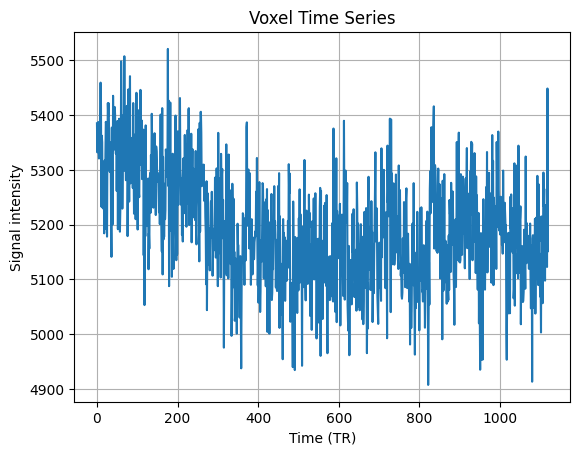

In [14]:
# Load BOLD (volume)
img = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/func/sub-01_ses-15_task-RestingState_dir-pa_space-fsLR_den-91k_bold.dtseries.nii')
data = img.get_fdata()  # shape: X x Y x Z x T

# Pick a voxel (e.g., center of brain)
voxel_ts = data[:, 100]  # adjust to actual GM

# Plot
plt.plot(voxel_ts)
plt.title("Voxel Time Series")
plt.xlabel("Time (TR)")
plt.ylabel("Signal intensity")
plt.grid(True)
plt.show()

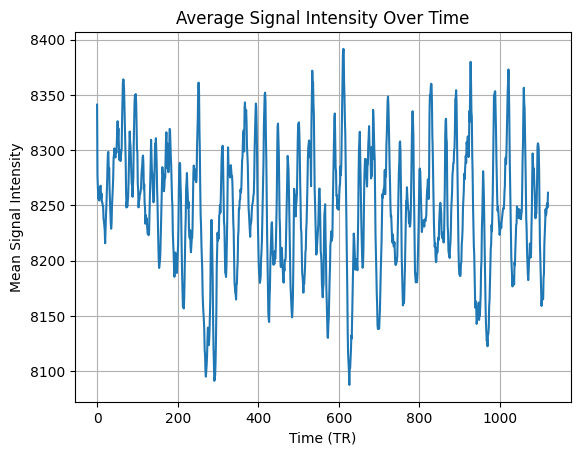

In [15]:
# Calculate the mean signal intensity across all voxels for each time point
mean_signal = np.mean(data, axis=1)

# Plot the average trend over time
plt.plot(mean_signal)
plt.title("Average Signal Intensity Over Time")
plt.xlabel("Time (TR)")
plt.ylabel("Mean Signal Intensity")
plt.grid(True)
plt.show()

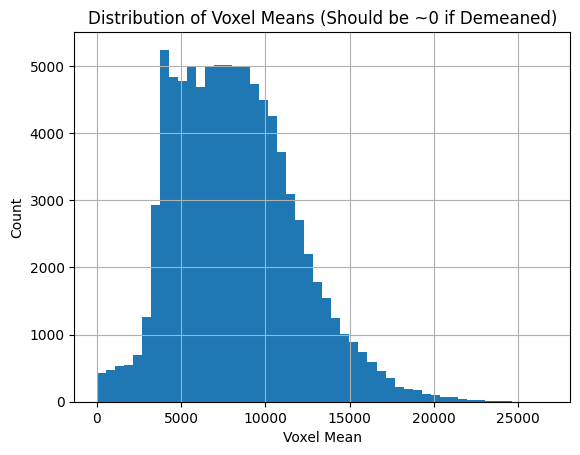

Mean of voxel means: 8245.920844573258
Std of voxel means: 3606.170036405976


In [16]:
# Check if data is demeaned: mean across time for each voxel
voxel_means = np.mean(data, axis=0)

plt.hist(voxel_means, bins=50)
plt.title("Distribution of Voxel Means (Should be ~0 if Demeaned)")
plt.xlabel("Voxel Mean")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Optionally, print the overall mean and standard deviation
print("Mean of voxel means:", np.mean(voxel_means))
print("Std of voxel means:", np.std(voxel_means))
# ...existing code...

## Check Nifti

In [26]:
# Load the specified NIfTI file with 91k vertices
demean_detrend = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_demean_detrend.dtseries.nii')
detrended_nomw = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_detrended_nomw.dtseries.nii')
before_l = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_L.func.gii')
nomw_l = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_L.nomw.func.gii')
subcortical = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_subcort.nii.gz')

# Get the data from the file
demean_detrend = demean_detrend.get_fdata()
detrended_nomw = detrended_nomw.get_fdata()
befire_l = before_l.darrays[0].data
nomw_l = nomw_l.darrays[0].data
subcortical_data = subcortical.get_fdata()

# Print basic information about the data
print("Shape of the data before:", demean_detrend.shape)
print("Shape of the data after:", detrended_nomw.shape)
print("Shape of the left hemisphere before:", befire_l.shape)
print("Shape of the left hemisphere after:", nomw_l.shape)
print("Shape of the subcortical data:", subcortical_data.shape)

Shape of the data before: (1120, 91282)
Shape of the data after: (1120, 96854)
Shape of the left hemisphere before: (32492,)
Shape of the left hemisphere after: (32492,)
Shape of the subcortical data: (55, 60, 50, 1120)


Shape of the data before: (1120, 91282)
Data type: float64
Shape of the data after: (1120, 59412)
Data type after processing: float64


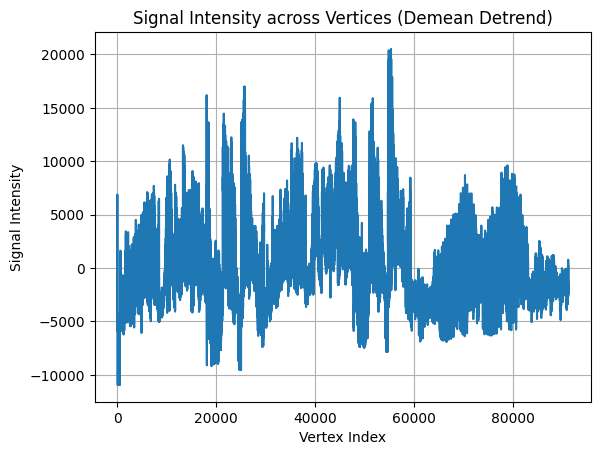

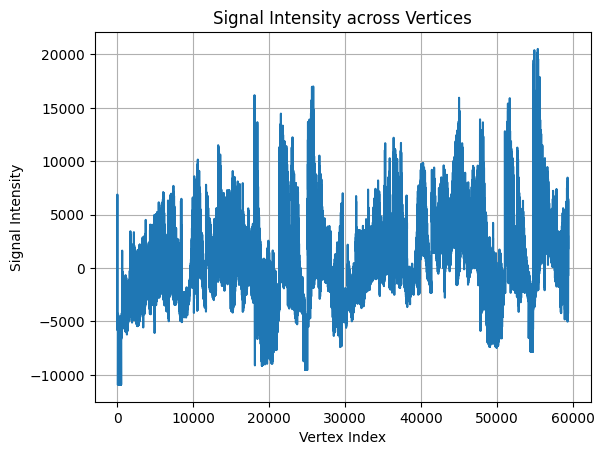

ValueError: operands could not be broadcast together with shapes (1120,91282) (1120,59412) 

In [ ]:
# Load the specified NIfTI file with 91k vertices
demean_detrend = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_demean_detrend.dtseries.nii')
detrended_nomw = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_detrended_nomw.dtseries.nii')

# Get the data from the file
demean_detrend = demean_detrend.get_fdata()
detrended_nomw = detrended_nomw.get_fdata()

# Print basic information about the data
print("Shape of the data before:", demean_detrend.shape)
print("Data type:", demean_detrend.dtype)
print("Shape of the data after:", detrended_nomw.shape)
print("Data type after processing:", detrended_nomw.dtype)

# If it's a time series, visualize the time series for a specific vertex/voxel
if len(demean_detrend.shape) == 2:  # Typically (time, vertices/voxels)
    plt.plot(demean_detrend[0, :])  # Plot the signal intensity for the first time point across all vertices
    plt.title("Signal Intensity across Vertices (Demean Detrend)")
    plt.xlabel("Vertex Index")
    plt.ylabel("Signal Intensity")
    plt.grid(True)
    plt.show()
else:
    print("Unexpected data shape. Visualization may need adjustment.")

if len(detrended_nomw.shape) == 2:  # Typically (time, vertices/voxels)
    plt.plot(detrended_nomw[0, :])  # Plot the signal intensity for the first time point across all vertices
    plt.title("Signal Intensity across Vertices")
    plt.xlabel("Vertex Index")
    plt.ylabel("Signal Intensity")
    plt.grid(True)
    plt.show()
else:
    print("Unexpected data shape. Visualization may need adjustment.")

# Print which voxels differ from demean_detrend and detrended_nomw
diff_voxels = np.where(demean_detrend != detrended_nomw)
print("Indices of differing voxels:", diff_voxels)

In [29]:
import nibabel as nib
img = nib.load("/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_detrended_nomw.dtseries.nii")
print(img.get_fdata().shape)
print(img.header.matrix.get_index_map(1).number_of_rows)

(1120, 91282)


AttributeError: 'Cifti2MatrixIndicesMap' object has no attribute 'number_of_rows'

In [11]:
# Load the specified NIfTI file with medial wall removed
nifti_file = nib.load('/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_subcort.nii.gz')

# Get the data from the file
nifti_data = nifti_file.get_fdata()

# Print basic information about the data
print("Shape of the CIFTI-2 data:", nifti_data.shape)
print("Data type:", nifti_data.dtype)

# If it's a time series, visualize the time series for a specific vertex/voxel
if len(nifti_data.shape) == 2:  # Typically (time, vertices/voxels)
    plt.plot(nifti_data[0, :])  # Plot the signal intensity for the first time point across all vertices
    plt.title("Signal Intensity across Vertices")
    plt.xlabel("Vertex Index")
    plt.ylabel("Signal Intensity")
    plt.grid(True)
    plt.show()
else:
    print("Unexpected data shape. Visualization may need adjustment.")

Shape of the CIFTI-2 data: (91, 109, 91, 1120)
Data type: float64
Unexpected data shape. Visualization may need adjustment.


## Check Data Type

In [12]:
import nibabel as nib
img = nib.load("/ptmp/hmueller2/Downloads/fmriprep_out/sub-01/ses-15/postfmriprep/demean/sub-01_ses-15_task-RestingState_dir-pa_subcort.nii.gz")
print(f"Data type: {img.get_data_dtype()}")

Data type: float32


## Rename postfmriprep to postfmriprep_scrubbed

In [ ]:
import os

# Read the subjects from the file
subjects =  "/ptmp/hmueller2/Downloads/subjects_resting.txt"

base_dir = "/ptmp/hmueller2/Downloads/fmriprep_out"
folders = []

# Collect all postfmriprep folders for the given subjects
for subject in subjects:
    subj_dir = os.path.join(base_dir, f"sub-{subject}")
    if not os.path.isdir(subj_dir):
        continue
    for ses in os.listdir(subj_dir):
        if ses.startswith("ses-"):
            folder_path = os.path.join(subj_dir, ses, "postfmriprep")
            if os.path.isdir(folder_path):
                folders.append(folder_path)

# Rename the filtered folders
for folder in folders:
    new_folder = folder.replace("postfmriprep", "postfmriprep_scrubbed")
    os.rename(folder, new_folder)
    print(f"Renamed: {folder} -> {new_folder}")


Renamed: /ptmp/hmueller2/Downloads/fmriprep_out/sub-14/ses-40/postfmriprep -> /ptmp/hmueller2/Downloads/fmriprep_out/sub-14/ses-40/postfmriprep_scrubbed
Renamed: /ptmp/hmueller2/Downloads/fmriprep_out/sub-14/ses-03/postfmriprep -> /ptmp/hmueller2/Downloads/fmriprep_out/sub-14/ses-03/postfmriprep_scrubbed
Renamed: /ptmp/hmueller2/Downloads/fmriprep_out/sub-14/ses-13/postfmriprep -> /ptmp/hmueller2/Downloads/fmriprep_out/sub-14/ses-13/postfmriprep_scrubbed
Renamed: /ptmp/hmueller2/Downloads/fmriprep_out/sub-14/ses-24/postfmriprep -> /ptmp/hmueller2/Downloads/fmriprep_out/sub-14/ses-24/postfmriprep_scrubbed
Renamed: /ptmp/hmueller2/Downloads/fmriprep_out/sub-14/ses-23/postfmriprep -> /ptmp/hmueller2/Downloads/fmriprep_out/sub-14/ses-23/postfmriprep_scrubbed
Renamed: /ptmp/hmueller2/Downloads/fmriprep_out/sub-14/ses-34/postfmriprep -> /ptmp/hmueller2/Downloads/fmriprep_out/sub-14/ses-34/postfmriprep_scrubbed
Renamed: /ptmp/hmueller2/Downloads/fmriprep_out/sub-14/ses-08/postfmriprep -> /ptm

### Check scrubbing disabled

In [4]:
# compare these two files (maybe in shape or mean activation or first few values)

import nibabel as nib
import numpy as np

path_unscrubbed = "/ptmp/hmueller2/Downloads/fmriprep_out/sub-07/ses-08/postfmriprep/GLM/"
path_scrubbed = "/ptmp/hmueller2/Downloads/fmriprep_out/sub-07/ses-08/postfmriprep_scrubbed/GLM/" 

run_unscrubbed = "sub-07_ses-08_task-ClipsTrn_dir-pa_run-11_cleaned_noscrub.dtseries.nii"
run_scrubbed = "sub-07_ses-08_task-ClipsTrn_dir-pa_run-11_cleaned.dtseries.nii"

# Load the two files
unscrubbed_img = nib.load(path_unscrubbed + run_unscrubbed)
scrubbed_img = nib.load(path_scrubbed + run_scrubbed)

# Get the data
unscrubbed_data = unscrubbed_img.get_fdata()
scrubbed_data = scrubbed_img.get_fdata()

# Compare shapes
print("Shape of unscrubbed data:", unscrubbed_data.shape)
print("Shape of scrubbed data:", scrubbed_data.shape)

# Compare mean activation
print("Mean activation (unscrubbed):", round(np.mean(unscrubbed_data), 2))
print("Mean activation (scrubbed):", round(np.mean(scrubbed_data), 2))

Shape of unscrubbed data: (320, 91282)
Shape of scrubbed data: (290, 91282)
Mean activation (unscrubbed): -0.0
Mean activation (scrubbed): -0.0


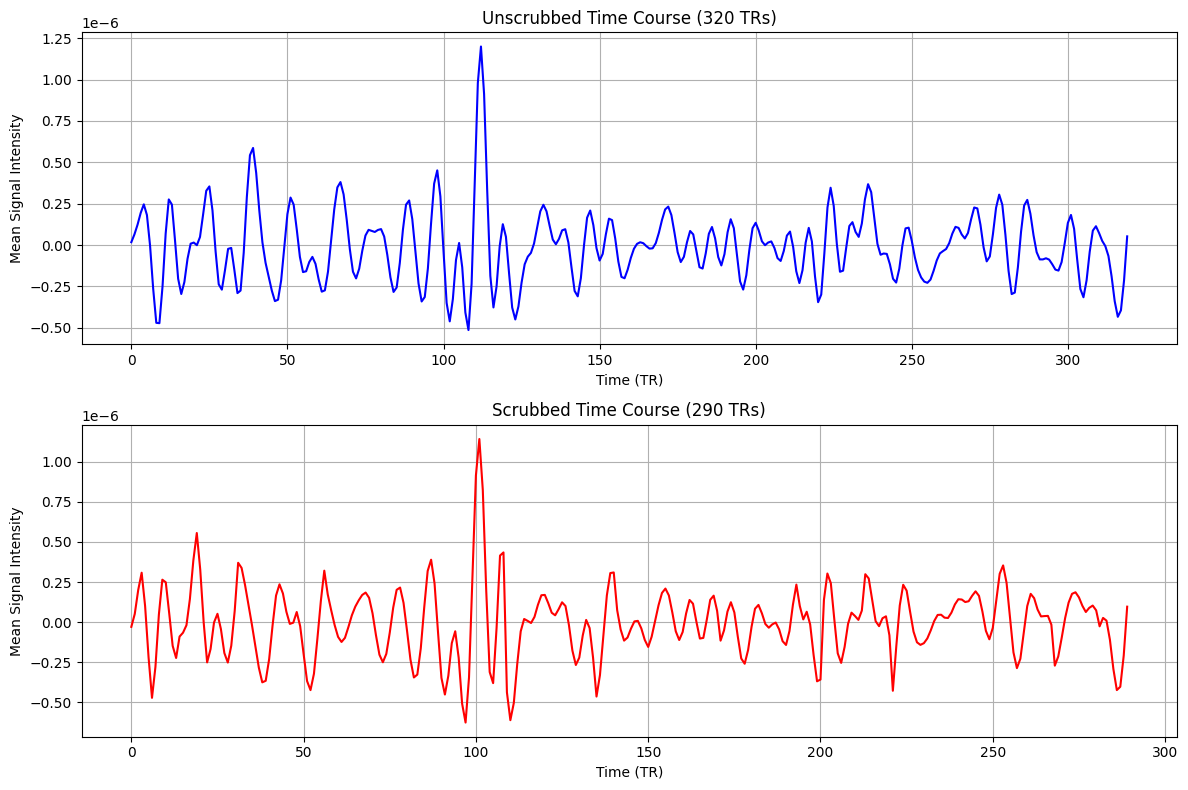

Standard deviation (unscrubbed): 2.1573e-07
Standard deviation (scrubbed): 2.1986e-07
Unscrubbed time course length: 320
Mean of unscrubbed time course: -7.7057e-09
Mean of scrubbed time course: -2.7604e-09
Range of unscrubbed time course: 1.7131e-06
Range of scrubbed time course: 1.7678e-06
Correlation of mean patterns across voxels: 0.3939


In [11]:
import matplotlib.pyplot as plt

path_unscrubbed = "/ptmp/hmueller2/Downloads/fmriprep_out/sub-07/ses-08/postfmriprep/GLM/"
path_scrubbed = "/ptmp/hmueller2/Downloads/fmriprep_out/sub-07/ses-08/postfmriprep_scrubbed/GLM/" 

run_unscrubbed = "sub-07_ses-08_task-ClipsTrn_dir-pa_run-11_cleaned_noscrub.dtseries.nii"
run_scrubbed = "sub-07_ses-08_task-ClipsTrn_dir-pa_run-11_cleaned.dtseries.nii"

# Plot the average time course across all vertices for both files
mean_timecourse_unscrubbed = np.mean(unscrubbed_data, axis=1)
mean_timecourse_scrubbed = np.mean(scrubbed_data, axis=1)

# Create two separate subplots for better comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Plot unscrubbed time course
ax1.plot(np.arange(len(mean_timecourse_unscrubbed)), mean_timecourse_unscrubbed, color='blue')
ax1.set_title("Unscrubbed Time Course (320 TRs)")
ax1.set_ylabel("Mean Signal Intensity")
ax1.set_xlabel("Time (TR)")
ax1.grid(True)

# Plot scrubbed time course
ax2.plot(np.arange(len(mean_timecourse_scrubbed)), mean_timecourse_scrubbed, color='red')
ax2.set_title("Scrubbed Time Course (290 TRs)")
ax2.set_ylabel("Mean Signal Intensity")
ax2.set_xlabel("Time (TR)")
ax2.grid(True)

plt.tight_layout()
plt.show()

# 1) Compute standard deviation of the time series
std_unscrubbed = np.std(mean_timecourse_unscrubbed)
std_scrubbed = np.std(mean_timecourse_scrubbed)

print(f"Standard deviation (unscrubbed): {std_unscrubbed:.4e}")
print(f"Standard deviation (scrubbed): {std_scrubbed:.4e}")

# 2) Since the time courses have different lengths, we can't directly compare them
print(f"Unscrubbed time course length: {len(mean_timecourse_unscrubbed)}")
# Instead of direct comparison, we can compare summary statistics
print(f"Mean of unscrubbed time course: {np.mean(mean_timecourse_unscrubbed):.4e}")
print(f"Mean of scrubbed time course: {np.mean(mean_timecourse_scrubbed):.4e}")

# Compare ranges
range_unscrubbed = np.max(mean_timecourse_unscrubbed) - np.min(mean_timecourse_unscrubbed)
range_scrubbed = np.max(mean_timecourse_scrubbed) - np.min(mean_timecourse_scrubbed)
print(f"Range of unscrubbed time course: {range_unscrubbed:.4e}")
print(f"Range of scrubbed time course: {range_scrubbed:.4e}")

# Optional: Compute correlation between means across voxels
# This would tell us if the spatial patterns are similar
mean_across_voxels_unscrubbed = np.mean(unscrubbed_data, axis=0)
mean_across_voxels_scrubbed = np.mean(scrubbed_data, axis=0)
correlation = np.corrcoef(mean_across_voxels_unscrubbed, mean_across_voxels_scrubbed)[0, 1]
print(f"Correlation of mean patterns across voxels: {correlation:.4f}")


### Check if preprocessing worked for all

In [12]:
import os

subjects_file = "/ptmp/hmueller2/Downloads/subjects_resting.txt"
base_dir = "/ptmp/hmueller2/Downloads/fmriprep_out"

# Read subject IDs from file
with open(subjects_file, "r") as f:
    subject_ids = [line.strip() for line in f if line.strip()]

for subject in subject_ids:
    subj_dir = os.path.join(base_dir, f"sub-{subject}")
    if not os.path.isdir(subj_dir):
        print(f"Subject directory not found: {subj_dir}")
        continue
    for ses in os.listdir(subj_dir):
        if ses.startswith("ses-"):
            folder_path = os.path.join(subj_dir, ses, "postfmriprep")
            if os.path.isdir(folder_path):
                print(f"Found: {folder_path}")
            else:
                print(f"Missing: {folder_path}")

Found: /ptmp/hmueller2/Downloads/fmriprep_out/sub-04/ses-40/postfmriprep
Found: /ptmp/hmueller2/Downloads/fmriprep_out/sub-04/ses-03/postfmriprep
Found: /ptmp/hmueller2/Downloads/fmriprep_out/sub-04/ses-13/postfmriprep
Found: /ptmp/hmueller2/Downloads/fmriprep_out/sub-04/ses-24/postfmriprep
Found: /ptmp/hmueller2/Downloads/fmriprep_out/sub-04/ses-23/postfmriprep
Found: /ptmp/hmueller2/Downloads/fmriprep_out/sub-04/ses-34/postfmriprep
Found: /ptmp/hmueller2/Downloads/fmriprep_out/sub-04/ses-07/postfmriprep
Found: /ptmp/hmueller2/Downloads/fmriprep_out/sub-04/ses-18/postfmriprep
Found: /ptmp/hmueller2/Downloads/fmriprep_out/sub-04/ses-17/postfmriprep
Found: /ptmp/hmueller2/Downloads/fmriprep_out/sub-04/ses-39/postfmriprep
Found: /ptmp/hmueller2/Downloads/fmriprep_out/sub-04/ses-38/postfmriprep
Found: /ptmp/hmueller2/Downloads/fmriprep_out/sub-04/ses-00/postfmriprep
Found: /ptmp/hmueller2/Downloads/fmriprep_out/sub-04/ses-21/postfmriprep
Found: /ptmp/hmueller2/Downloads/fmriprep_out/sub-0

In [6]:
import nibabel as nib
import numpy as np

# For kmeans, check shape of "Bipartite_PhysicalCommunities+AlgorithmicLabeling.dlabel.nii"
# Path: /ptmp/hmueller2/Downloads/individual_networks/sub-04/resting_state/
# Path to the file
file_path = "/ptmp/hmueller2/Downloads/individual_networks/sub-04/resting_state/Bipartite_PhysicalCommunities+AlgorithmicLabeling.dlabel.nii"

# Load the file
label_img = nib.load(file_path)

# Get basic information
print("File info:")
print(f"Shape: {label_img.shape}")
print(f"Data type: {label_img.get_data_dtype()}")

# Get the data
label_data = label_img.get_fdata()
print("\nData stats:")
print(f"Unique values: {np.unique(label_data)}")
print(f"Min value: {np.min(label_data)}")
print(f"Max value: {np.max(label_data)}")
print(f"Number of unique labels: {len(np.unique(label_data))}")

File info:
Shape: (1, 91282)
Data type: float32

Data stats:
Unique values: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20.]
Min value: 0.0
Max value: 20.0
Number of unique labels: 21
